In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from gan_data_gen import load_data_for_wgan, get_mean_std_error
from wgan import compare_dfs
import numpy as np

In [12]:
maxepochs_range = [2500, 5000, 7500]
dropout = 0.0
batchsize_range = [128, 256, 512]
lr = 1e-3

def get_train_data():
    df_train, _ = load_data_for_wgan('data/train.parquet')
    pos_vars = ["hh_wgt", "consumption_per_capita_per_day", "popdensity", "yearly_rent"]
    for var in pos_vars:
        df_train[var] = np.exp(df_train["log_" + var])
        df_train.drop(columns=["log_" + var], inplace=True)
    return df_train

def get_synthetic_data(maxepochs, lr, batchsize, dropout, trial):
    df_synthetic = pd.read_parquet(f'data/synthetic-maxepochs={maxepochs}_lr={lr}_batchsize={batchsize}_dropout={dropout}_trial={trial}_n=20000.parquet')
    return df_synthetic

df_train = get_train_data()

hparams = []
for trial in range(5):
    for maxepochs in maxepochs_range:
        for batchsize in batchsize_range:
            df_synthetic = get_synthetic_data(maxepochs, lr, batchsize, dropout, trial)
            mean_rmae, std_rmae = get_mean_std_error(df_train, df_synthetic)
            hparams.append({"maxepochs": maxepochs, "batchsize": batchsize, "mean_error": mean_rmae, "std_error": std_rmae, "total_error": mean_rmae + std_rmae, "trial":trial})

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dryrun/lib/python3.8/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/tmp/ipykernel_3445791/3835212709.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[var] = np.exp(df_train["log_" + var])
/tmp/ipykernel_3445791/3835212709.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

In [13]:
df = pd.DataFrame.from_records(hparams)
df.groupby(["maxepochs", "batchsize"]).agg(["mean", "std"])

mean_error           std_error           total_error  \
                          mean       std      mean       std        mean   
maxepochs batchsize                                                        
2500      128         0.024293  0.002891  0.085919  0.006671    0.110213   
          256         0.038446  0.024824  0.144521  0.061541    0.182967   
          512         0.081381  0.027401  0.270797  0.069616    0.352178   
5000      128         0.029441  0.003234  0.085646  0.010559    0.115087   
          256         0.032997  0.021128  0.124008  0.057949    0.157005   
          512         0.086297  0.018241  0.276938  0.023921    0.363235   
7500      128         0.026101  0.002457  0.070534  0.011157    0.096636   
          256         0.023478  0.003438  0.097191  0.026661    0.120669   
          512         0.074586  0.031207  0.221269  0.062429    0.295855   

                              trial            
                          std  mean       std  
maxepochs batchsize                            
2500      128        0.007040   2.0  1.581139  
          256        0.085501   2.0  1.581139  
          512        0.096454   2.0  1.581139  
5000      128        0.012709   2.0  1.581139  
          256        0.076579   2.0  1.581139  
          512        0.035658   2.0  1.581139  
7500      128        0.010063   2.0  1.581139  
          256        0.030015   2.0  1.581139  
          512        0.093524   2.0  1.581139

In [14]:
df1 = get_train_data()
df2 = get_synthetic_data(7500, lr, 128, dropout, 0)

/home/users/rsahoo/zfs/gsb/intermediate-yens/rsahoo/poverty/dryrun/lib/python3.8/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1808.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]
/tmp/ipykernel_3445791/3835212709.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train[var] = np.exp(df_train["log_" + var])
/tmp/ipykernel_3445791/3835212709.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once

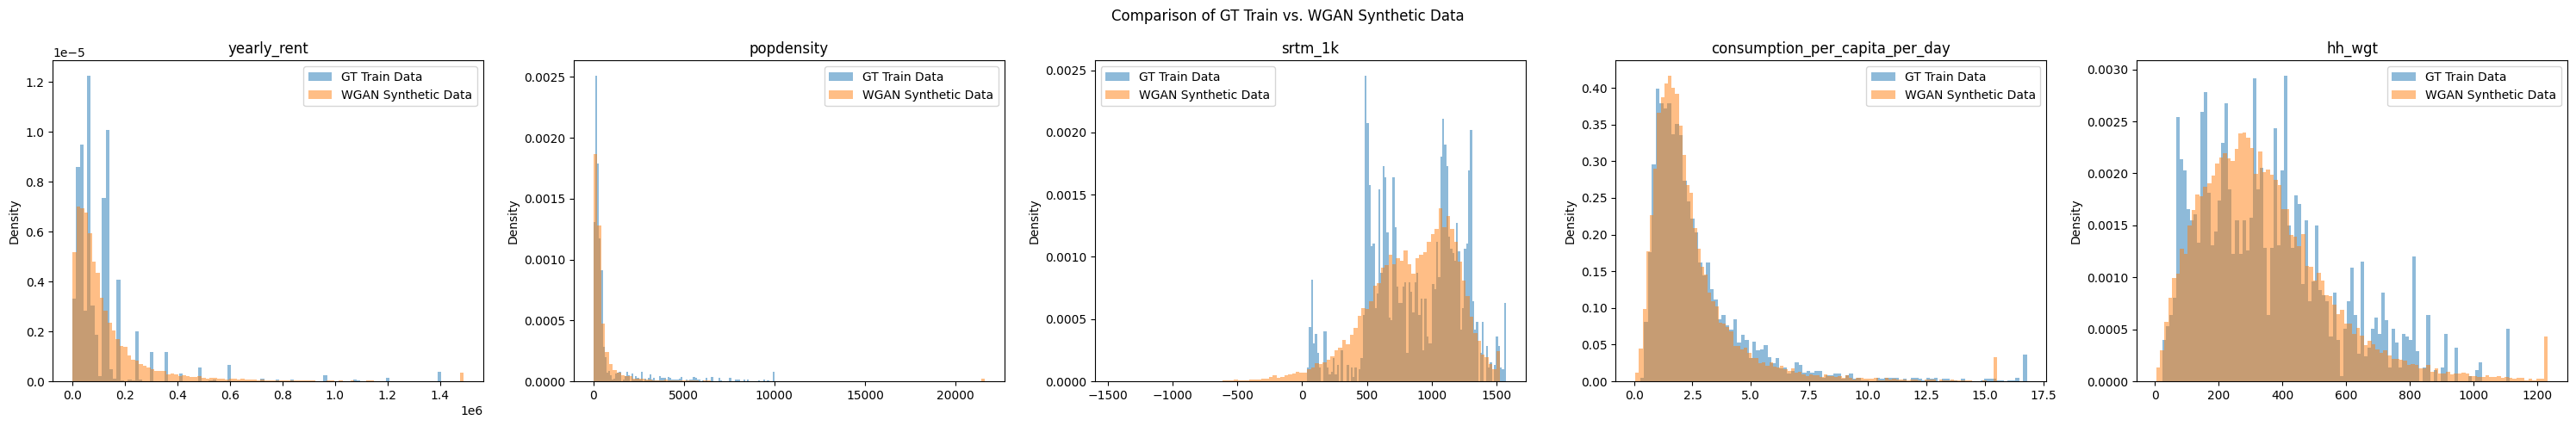

In [15]:
fig, axs = plt.subplots(1, 5, figsize=(30, 5))

features = ['yearly_rent', 'popdensity', 'srtm_1k', 'consumption_per_capita_per_day', 'hh_wgt']

plt.suptitle('Comparison of GT Train vs. WGAN Synthetic Data')

for i, feature in enumerate(features):
    axs[i].hist(np.clip(df1[feature], None, np.quantile(df1[feature], 0.995)), alpha=0.5, label='GT Train Data', density=True, bins=100)
    axs[i].hist(np.clip(df2[feature], None, np.quantile(df2[feature], 0.995)), alpha=0.5, label='WGAN Synthetic Data', density=True, bins=100)
    axs[i].set_title(feature)
    axs[i].set_ylabel('Density')
    axs[i].legend()
plt.tight_layout()
plt.savefig("figs/wgan.pdf")

